# Notebook 03a — TF-IDF Exploration

**Purpose:** Identify words in `blurb` (short description) and `name` (campaign title) that are strongly associated with campaign success or failure.

**Workflow:**
1. Fit TF-IDF on **training data only**
2. For each term, compute the **success rate** of campaigns that contain it
3. Rank terms by association with success/failure
4. Export a shortlist of predictive words → used in `03b_feature_engineering.ipynb` as binary features

**Key principle:** Term selection is based on training data only. The resulting word list is then applied to train, val, and test splits in notebook 03b.

## Setup

In [7]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

OUTPUTS_PATH = 'data'   # reads from notebook 01; saves tfidf_word_list.json here
FIGURES_PATH = os.path.join(OUTPUTS_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)

train_df = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'train_df.parquet'))

print(f'Train: {train_df.shape}')
from statsmodels.stats.proportion import proportions_ztest


Train: (102887, 16)


## Step 1 — TF-IDF on `blurb`

We fit TF-IDF on training data only with the following settings:
- `min_df=50`: a word must appear in at least 50 campaigns to be included (avoids rare noise)
- `max_df=0.8`: ignore words appearing in more than 80% of campaigns (too common to be informative)
- `ngram_range=(1,2)`: include single words and two-word phrases
- `stop_words='english'`: remove common English stop words

In [8]:
blurb_train = train_df['blurb'].fillna('').astype(str)

# Fit on training data only
tfidf_blurb = TfidfVectorizer(
    min_df=50,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)
X_blurb_train = tfidf_blurb.fit_transform(blurb_train)

vocab_blurb = tfidf_blurb.get_feature_names_out()
print(f'Vocabulary size (blurb): {len(vocab_blurb):,} terms')
print(f'Matrix shape (train)   : {X_blurb_train.shape}')

Vocabulary size (blurb): 3,856 terms
Matrix shape (train)   : (102887, 3856)


## Step 2 — Success Rate per Term (blurb)

For each term, we compute:
- `n`: number of campaigns whose blurb contains the term
- `success_rate`: mean success rate among those campaigns
- `lift`: success_rate / global_mean — how much better/worse than average
- `z_score` / `p_value`: statistical significance of the difference from global mean

In [9]:
y_train = train_df['success'].values
global_mean = y_train.mean()
print(f'Global success rate: {global_mean*100:.1f}%')

# Binary presence matrix (1 = term appears in blurb)
presence = (X_blurb_train > 0).toarray()

rows = []
for i, term in enumerate(vocab_blurb):
    mask = presence[:, i]
    n = mask.sum()
    if n < 50:
        continue
    sr = y_train[mask].mean()
    # Two-proportion z-test vs global mean
    z, p = proportions_ztest(y_train[mask].sum(), n, value=global_mean)
    rows.append({'term': term, 'n': int(n), 'success_rate': sr, 'lift': sr / global_mean, 'z': z, 'p_value': p})

blurb_stats = pd.DataFrame(rows).sort_values('success_rate', ascending=False)
print(f'Terms analysed: {len(blurb_stats):,}')
print(f'Significant (p<0.01): {(blurb_stats["p_value"] < 0.01).sum():,}')

Global success rate: 56.9%
Terms analysed: 3,856
Significant (p<0.01): 1,672


## Step 3 — Top Predictive Terms (blurb)

In [10]:
# Filter: significant (p<0.01) and at least 200 campaigns
sig = blurb_stats[blurb_stats['p_value'] < 0.01].copy()

top_positive = sig[sig['lift'] > 1].nlargest(20, 'lift')
top_negative = sig[sig['lift'] < 1].nsmallest(20, 'lift')

print('=== Top 20 terms associated with SUCCESS (blurb) ===')
print(top_positive[['term','n','success_rate','lift','p_value']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              lift=lambda x: x['lift'].round(3),
              p_value=lambda x: x['p_value'].apply(lambda v: f'{v:.2e}'))
      .to_string(index=False))

print()
print('=== Top 20 terms associated with FAILURE (blurb) ===')
print(top_negative[['term','n','success_rate','lift','p_value']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              lift=lambda x: x['lift'].round(3),
              p_value=lambda x: x['p_value'].apply(lambda v: f'{v:.2e}'))
      .to_string(index=False))

=== Top 20 terms associated with SUCCESS (blurb) ===
              term   n  success_rate  lift   p_value
      stretch goal  68         100.0 1.757  0.00e+00
length documentary  67          98.5 1.731 2.15e-173
        comedy web  54          98.1 1.724 8.01e-112
    animated short  84          97.6 1.715 3.45e-132
 short documentary  72          97.2 1.708  3.65e-96
     length studio  60          96.7 1.698  6.26e-66
           quartet  90          96.7 1.698  5.95e-98
        watercolor  88          96.6 1.697  1.87e-93
  children picture  56          96.4 1.694  3.89e-57
  book celebrating  54          96.3 1.692  5.56e-53
         stl files  50          96.0 1.686  3.75e-45
       stop motion  73          95.9 1.685  3.92e-63
             sarah  66          95.5 1.677  4.80e-51
               ita  67          94.0 1.652  1.28e-37
  documentary film 167          94.0 1.652  9.58e-91
  comics anthology  64          93.8 1.647  4.42e-34
          art book 253          93.7 1.646 1.7

## Step 4 — Visualisation (blurb)

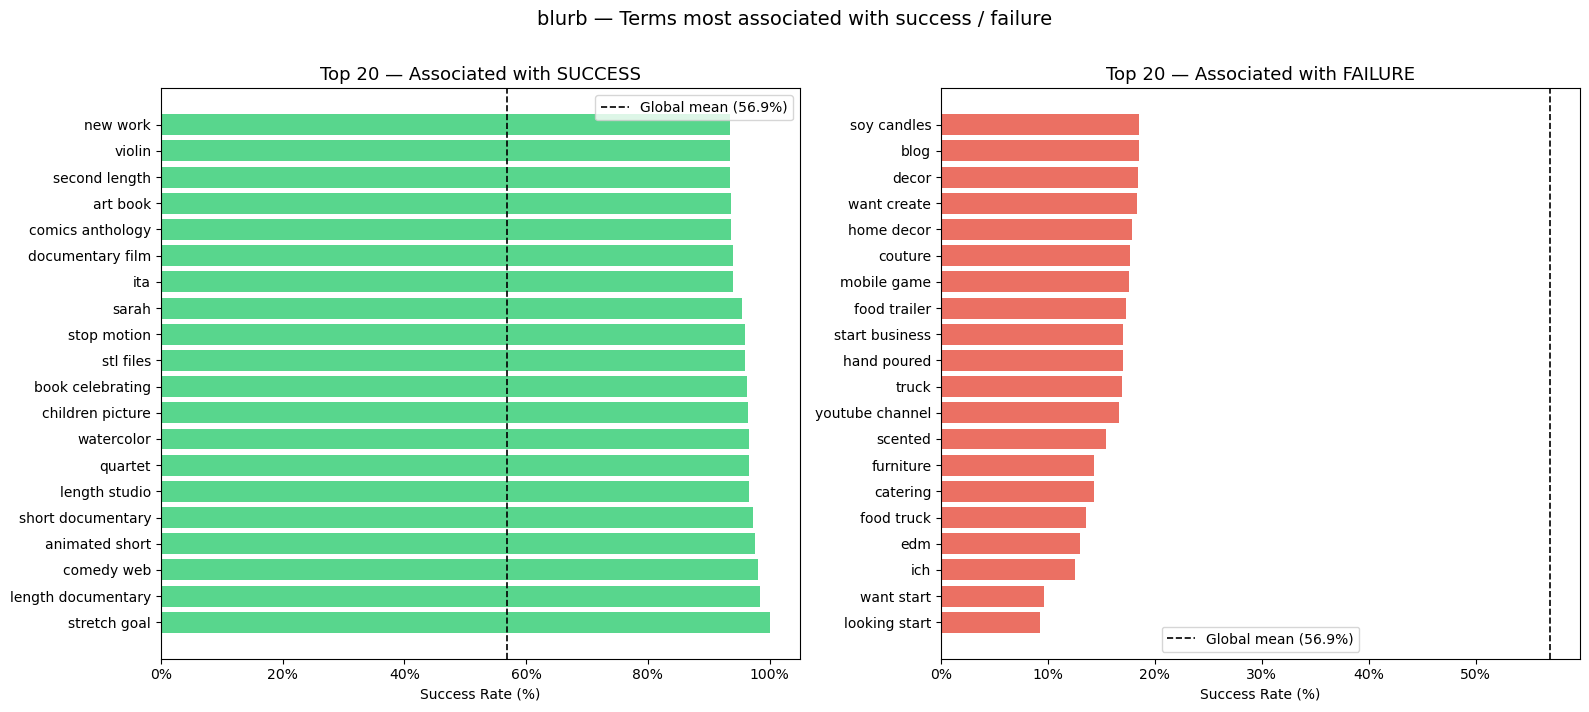

Saved tfidf_blurb_top_terms.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, color in [
    (axes[0], top_positive, 'Top 20 — Associated with SUCCESS', '#2ecc71'),
    (axes[1], top_negative.sort_values('lift'), 'Top 20 — Associated with FAILURE', '#e74c3c')
]:
    bars = ax.barh(data['term'], (data['success_rate'] * 100), color=color, alpha=0.8)
    ax.axvline(global_mean * 100, color='black', linestyle='--', linewidth=1.2, label=f'Global mean ({global_mean*100:.1f}%)')
    ax.set_xlabel('Success Rate (%)')
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('blurb — Terms most associated with success / failure', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'tfidf_blurb_top_terms.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved tfidf_blurb_top_terms.png')

## Step 5 — TF-IDF on `name` (campaign title)

In [12]:
name_train = train_df['name'].fillna('').astype(str)

tfidf_name = TfidfVectorizer(
    min_df=50,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)
X_name_train = tfidf_name.fit_transform(name_train)
vocab_name = tfidf_name.get_feature_names_out()
print(f'Vocabulary size (name): {len(vocab_name):,} terms')

presence_name = (X_name_train > 0).toarray()
rows_name = []
for i, term in enumerate(vocab_name):
    mask = presence_name[:, i]
    n = mask.sum()
    if n < 50:
        continue
    sr = y_train[mask].mean()
    z, p = proportions_ztest(y_train[mask].sum(), n, value=global_mean)
    rows_name.append({'term': term, 'n': int(n), 'success_rate': sr, 'lift': sr / global_mean, 'z': z, 'p_value': p})

name_stats = pd.DataFrame(rows_name).sort_values('success_rate', ascending=False)
sig_name = name_stats[name_stats['p_value'] < 0.01]

print()
print('=== Top 15 terms associated with SUCCESS (name) ===')
print(sig_name[sig_name['lift'] > 1].nlargest(15, 'lift')[['term','n','success_rate','lift','p_value']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              lift=lambda x: x['lift'].round(3),
              p_value=lambda x: x['p_value'].apply(lambda v: f'{v:.2e}'))
      .to_string(index=False))

print()
print('=== Top 15 terms associated with FAILURE (name) ===')
print(sig_name[sig_name['lift'] < 1].nsmallest(15, 'lift')[['term','n','success_rate','lift','p_value']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              lift=lambda x: x['lift'].round(3),
              p_value=lambda x: x['p_value'].apply(lambda v: f'{v:.2e}'))
      .to_string(index=False))

Vocabulary size (name): 1,460 terms

=== Top 15 terms associated with SUCCESS (name) ===
            term   n  success_rate  lift   p_value
  nude photobook  51         100.0 1.757  0.00e+00
        plushies  56          98.2 1.725 2.07e-120
  animated short 132          97.7 1.717 3.39e-217
      3d printer 144          97.2 1.708 2.46e-190
           nudes  94          96.8 1.701 2.86e-107
         artbook  54          96.3 1.692  5.56e-53
      new length  53          96.2 1.690  5.79e-51
         ita bag  53          96.2 1.690  5.79e-51
             ita  75          96.0 1.686  7.93e-67
documentary film  75          96.0 1.686  7.93e-67
      new record  88          95.5 1.677  1.87e-67
       art nudes  66          95.5 1.677  4.80e-51
       paintings 127          95.3 1.674  2.96e-92
       residency  97          94.8 1.666  5.16e-64
    length album 218          94.0 1.652 1.81e-118

=== Top 15 terms associated with FAILURE (name) ===
         term   n  success_rate  lift   p_

## Step 6 — Category-Adjusted Diff & Export

Simply ranking by success rate risks selecting words that are high only because they appear in already-successful categories — a signal already captured by `cat_name_encoded`.

For each term we compute:
```
cat_avg_success = mean success rate of the categories that contain the term
diff = word_success_rate - cat_avg_success
```

A large positive `diff` means the word predicts success **beyond** what the category already explains.

**Selection criteria:**
- `p < 0.01` — statistically significant
- `n >= 200` — sufficient sample size
- `|diff| >= 10pt` — meaningful signal beyond category effect
- Year tokens (e.g. `2013`, `2012`) excluded — year effects were intentionally removed from the model
- Non-English tokens excluded (e.g. German: `und`, `ein`, `mit`; Spanish: `para`, `que`, `una`, `el`, `es`, `las`, `se`, `proyecto`; Italian: `di`) — these reflect the campaign's language rather than content, and language is already partially captured by `country_*` OHE features

In [13]:
import re

# Category success rate lookup (train only)
cat_success = train_df.groupby('cat_name')['success'].mean()

def add_diff(stats_df, presence_matrix, vocab_list, df_source):
    """Add cat_avg_success and diff columns to a stats DataFrame."""
    term_to_idx = {t: i for i, t in enumerate(vocab_list)}
    diffs = []
    for _, row in stats_df.iterrows():
        idx = term_to_idx.get(row['term'])
        if idx is None:
            diffs.append(np.nan)
            continue
        mask = presence_matrix[:, idx].astype(bool)
        cat_avg = df_source.loc[mask, 'cat_name'].map(cat_success).mean()
        diffs.append(row['success_rate'] - cat_avg)
    stats_df = stats_df.copy()
    stats_df['diff'] = diffs
    return stats_df

# Tokens to exclude
YEAR_PATTERN = re.compile(r'^\d{4}$')

# Non-English tokens: reflect language of campaign, not content.
# Language signal is partially captured by country_* OHE features.
NON_ENGLISH_TOKENS = {
    # German
    'und', 'ein', 'mit', 'ich', 'die', 'der', 'das',
    # Spanish
    'para', 'que', 'una', 'el', 'es', 'las', 'los', 'se', 'proyecto',
    # Italian
    'di', 'il', 'la', 'un',
}

def is_excluded(term):
    if YEAR_PATTERN.match(str(term)):
        return True
    # Check if any token in the term (could be bigram) is non-English
    tokens = str(term).lower().split()
    if any(t in NON_ENGLISH_TOKENS for t in tokens):
        return True
    return False

def shortlist(stats_df, presence_matrix, vocab_list, df_source, field,
              min_n=200, min_diff=0.10, p_thresh=0.01):
    df = add_diff(stats_df, presence_matrix, vocab_list, df_source)
    filtered = df[
        (df['p_value'] < p_thresh) &
        (df['n'] >= min_n) &
        (df['diff'].abs() >= min_diff) &
        (~df['term'].apply(is_excluded))
    ].copy()
    filtered['field'] = field
    return filtered.sort_values('diff', ascending=False)

blurb_vocab_list = list(tfidf_blurb.get_feature_names_out())
name_vocab_list  = list(tfidf_name.get_feature_names_out())

blurb_short = shortlist(blurb_stats, presence,      blurb_vocab_list, train_df, 'blurb')
name_short  = shortlist(name_stats,  presence_name, name_vocab_list,  train_df, 'name')

print(f'Shortlisted blurb terms: {len(blurb_short)}')
print(f'Shortlisted name  terms: {len(name_short)}')

print('\n=== BLURB — diff >= +10pt (success signal beyond category) ===')
pos_blurb = blurb_short[blurb_short['diff'] > 0]
print(pos_blurb[['term','n','success_rate','diff']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              diff=lambda x: (x['diff']*100).round(1))
      .to_string(index=False))

print('\n=== BLURB — diff <= -10pt (failure signal beyond category) ===')
neg_blurb = blurb_short[blurb_short['diff'] < 0].sort_values('diff')
print(neg_blurb[['term','n','success_rate','diff']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              diff=lambda x: (x['diff']*100).round(1))
      .to_string(index=False))

print('\n=== NAME — diff >= +10pt ===')
pos_name = name_short[name_short['diff'] > 0]
print(pos_name[['term','n','success_rate','diff']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              diff=lambda x: (x['diff']*100).round(1))
      .to_string(index=False))

print('\n=== NAME — diff <= -10pt ===')
neg_name = name_short[name_short['diff'] < 0].sort_values('diff')
print(neg_name[['term','n','success_rate','diff']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              diff=lambda x: (x['diff']*100).round(1))
      .to_string(index=False))

# Export
word_list = {
    'blurb': blurb_short[['term','n','success_rate','diff']].to_dict(orient='records'),
    'name' : name_short[['term','n','success_rate','diff']].to_dict(orient='records'),
}
with open(os.path.join(OUTPUTS_PATH, 'tfidf_word_list.json'), 'w') as f:
    json.dump(word_list, f, indent=2)
print('\nSaved tfidf_word_list.json')

Shortlisted blurb terms: 74
Shortlisted name  terms: 33

=== BLURB — diff >= +10pt (success signal beyond category) ===
           term    n  success_rate  diff
          queer  276          90.9  20.5
         fringe  337          84.9  19.3
      edinburgh  253          84.2  19.1
             pi  239          75.3  17.6
   raspberry pi  212          75.5  17.6
      raspberry  217          75.1  17.1
   installation  255          71.4  15.0
       downtown  219          68.0  15.0
limited edition  552          81.0  15.0
          issue  336          77.1  14.4
        edition  881          79.9  13.5
  collaboration  240          74.6  13.4
    celebrating  519          81.3  13.2
         annual  266          70.3  13.1
    hard enamel  327          90.5  13.0
          award  523          78.4  12.9
    enamel pins  592          90.7  12.7
         volume  345          80.0  12.7
  award winning  456          78.1  12.6
            nyc  394          74.4  12.3
        arduino  26

## Step 7 — Pairwise Correlation Check (shortlisted terms)

Binary features that correlate highly (≥ 0.8) carry near-identical information — one can be dropped without losing signal.

**Method:** For each high-correlation pair, drop the term with the lower `|diff|` (weaker signal beyond category effect). If both terms are already in the drop set, skip.

**Rationale for threshold = 0.8:** Binary features rarely reach 0.8+ correlation unless they are near-synonyms, substrings of each other, or co-occur almost exclusively (e.g. "raspberry" / "raspberry pi" / "pi").

In [14]:
def find_high_corr_pairs(short_df, presence_matrix, vocab_list, threshold=0.8):
    """Return DataFrame of high-correlation pairs among shortlisted binary features."""
    terms = short_df['term'].tolist()
    term_to_idx = {t: i for i, t in enumerate(vocab_list)}
    indices = [term_to_idx[t] for t in terms if t in term_to_idx]
    valid_terms = [t for t in terms if t in term_to_idx]

    mat = presence_matrix[:, indices].astype(np.float32)
    corr = np.corrcoef(mat.T)

    pairs = []
    n = len(valid_terms)
    for i in range(n):
        for j in range(i + 1, n):
            c = corr[i, j]
            if abs(c) >= threshold:
                pairs.append({'term_a': valid_terms[i], 'term_b': valid_terms[j], 'correlation': round(c, 3)})
    return pd.DataFrame(pairs).sort_values('correlation', ascending=False) if pairs else pd.DataFrame()


def get_drop_set(short_df, pairs_df):
    """Greedy drop: process pairs highest-corr first; drop the term with lower |diff|."""
    diff_map = dict(zip(short_df['term'], short_df['diff'].abs()))
    to_drop = set()
    reasons = {}
    for _, row in pairs_df.iterrows():
        ta, tb = row['term_a'], row['term_b']
        if ta in to_drop or tb in to_drop:
            continue  # already resolved
        drop = ta if diff_map.get(ta, 0) <= diff_map.get(tb, 0) else tb
        keep = tb if drop == ta else ta
        to_drop.add(drop)
        reasons[drop] = (
            f"dropped: corr={row['correlation']:.2f} with '{keep}' "
            f"(|diff| {diff_map[drop]*100:.1f}pt vs {diff_map[keep]*100:.1f}pt)"
        )
    return to_drop, reasons


blurb_pairs = find_high_corr_pairs(blurb_short, presence,      blurb_vocab_list)
name_pairs  = find_high_corr_pairs(name_short,  presence_name, name_vocab_list)

print(f'High-correlation blurb pairs (≥ 0.8): {len(blurb_pairs)}')
if not blurb_pairs.empty:
    print(blurb_pairs.to_string(index=False))

print(f'\nHigh-correlation name pairs  (≥ 0.8): {len(name_pairs)}')
if not name_pairs.empty:
    print(name_pairs.to_string(index=False))

blurb_drop, blurb_reasons = get_drop_set(blurb_short, blurb_pairs)
name_drop,  name_reasons  = get_drop_set(name_short,  name_pairs)

if blurb_drop:
    print('\nBlurb terms removed:')
    for t, r in blurb_reasons.items():
        print(f'  {t!r:30s}  {r}')
if name_drop:
    print('\nName terms removed:')
    for t, r in name_reasons.items():
        print(f'  {t!r:30s}  {r}')

blurb_short_clean = blurb_short[~blurb_short['term'].isin(blurb_drop)].copy()
name_short_clean  = name_short[~name_short['term'].isin(name_drop)].copy()

print(f'\nBlurb: {len(blurb_short)} → {len(blurb_short_clean)} terms')
print(f'Name : {len(name_short)}  → {len(name_short_clean)} terms')

# Overwrite json with deduplicated shortlists
word_list = {
    'blurb': blurb_short_clean[['term', 'n', 'success_rate', 'diff']].to_dict(orient='records'),
    'name' : name_short_clean[['term', 'n', 'success_rate', 'diff']].to_dict(orient='records'),
}
with open(os.path.join(OUTPUTS_PATH, 'tfidf_word_list.json'), 'w') as f:
    json.dump(word_list, f, indent=2)
print(f'\nSaved tfidf_word_list.json  ({len(blurb_short_clean)} blurb + {len(name_short_clean)} name terms)')

High-correlation blurb pairs (≥ 0.8): 8
         term_a        term_b  correlation
   raspberry pi     raspberry        0.988
             pi  raspberry pi        0.942
  award winning       winning        0.937
          award award winning        0.933
             pi     raspberry        0.931
          award       winning        0.878
limited edition       limited        0.817
    enamel pins          pins        0.802

High-correlation name pairs  (≥ 0.8): 2
     term_a term_b  correlation
enamel pins   pins        0.835
 enamel pin    pin        0.801

Blurb terms removed:
  'raspberry'                     dropped: corr=0.99 with 'raspberry pi' (|diff| 17.1pt vs 17.6pt)
  'raspberry pi'                  dropped: corr=0.94 with 'pi' (|diff| 17.6pt vs 17.6pt)
  'winning'                       dropped: corr=0.94 with 'award winning' (|diff| 11.3pt vs 12.6pt)
  'award winning'                 dropped: corr=0.93 with 'award' (|diff| 12.6pt vs 12.9pt)
  'limited'                       

## Next Step

Review the shortlisted terms above. Terms that make intuitive sense (e.g. genre words, effort signals) should be added as binary features in `03b_feature_engineering.ipynb`:

```python
# Example — to be added in notebook 03a after reviewing this output
for df in [train_df, val_df, test_df]:
    for term in selected_blurb_terms:
        col = 'blurb_has_' + term.replace(' ', '_')
        df[col] = df['blurb'].fillna('').str.contains(term, case=False, regex=False).astype(int)
```

**Important:** The term selection must be based on this notebook's output (training data only). Do not re-run term selection on the full dataset.